In [99]:
import torch 
import torch.nn as nn
import matplotlib.pyplot as plt

In [100]:
torch.manual_seed(42)
# Class 0
X0 = torch.randn(50, 2) + torch.tensor([-2., -2.])

# Class 1
X1 = torch.randn(50, 2) + torch.tensor([2., 2.])

X = torch.cat([X0, X1], dim=0)
y = torch.cat([
    torch.zeros(50, dtype=torch.long),
    torch.ones(50, dtype=torch.long)
])

print(X.shape)
print(y.shape)

torch.Size([100, 2])
torch.Size([100])


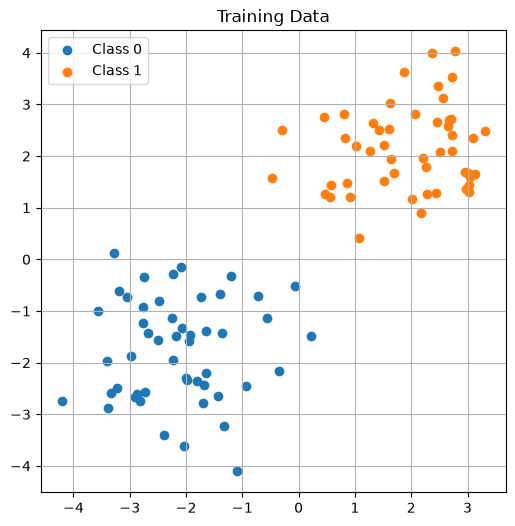

In [101]:
plt.figure(figsize=(6,6))

plt.scatter(X0[:,0], X0[:,1], label="Class 0")
plt.scatter(X1[:,0], X1[:,1], label="Class 1")

plt.legend()
plt.grid(True)
plt.title("Training Data")
plt.show()

In [102]:
def entropy(labels):

    if len(labels) == 0:
        return 0

    classes, counts = torch.unique(labels, return_counts = True)

    probs = counts.float() / len(labels)

    return -(probs * torch.log2(probs)).sum().item()

In [103]:
print(entropy(torch.tensor([0,0,0,0])))
print(entropy(torch.tensor([0,1,0,1])))

-0.0
1.0


In [104]:
def information_gain(X , y, feature, threshold):
    parent_entropy = entropy(y)

    left_mask  = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold

    left_y  = y[left_mask]
    right_y = y[right_mask]

    if len(left_y) == 0 or len (right_y) == 0:
        return 0

    n =len(y)

    left_weight  = len(left_y)  / n
    right_weight = len(right_y) / n

    child_entropy =(
        left_weight * entropy(left_y) + right_weight * entropy(right_y))

    return parent_entropy - child_entropy


In [105]:
def best_split(X, y):

    best_gain = -1

    split_feature = None
    split_threshold = None

    num_features = X.shape[1]

    for feature in range(num_features):

        thresholds = torch.unique(X[:, feature])

        for threshold in thresholds:

            gain = information_gain(X,y,feature,threshold.item())

            if gain > best_gain:

                best_gain = gain
                split_feature = feature
                split_threshold = threshold.item()

    return split_feature, split_threshold

In [106]:
# Tree node
class Node:

    def __init__(self,feature=None,threshold=None,left=None,right=None,value=None):

        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [107]:
def build_tree(X, y, depth=0, max_depth=3):

    # Stop if all labels are identical
    if len(torch.unique(y)) == 1:

        return Node(value=y[0].item())

    # Stop at maximum depth
    if depth >= max_depth:

        majority = torch.mode(y).values.item()
        return Node(value=majority)

    feature, threshold = best_split(X, y)

    if feature is None:

        majority = torch.mode(y).values.item()
        return Node(value=majority)

    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold

    left = build_tree(X[left_mask], y[left_mask], depth + 1, max_depth)

    right = build_tree(X[right_mask], y[right_mask], depth + 1, max_depth)

    return Node(feature=feature, threshold=threshold, left=left, right=right)

In [108]:
tree = build_tree(X, y, max_depth=3)

In [109]:
def predict_one(x,node):
    if node.value is not None:
        return node.value

    if x[node.feature] <= node.threshold:
        return predict_one(x,node.left)

    else:
        return predict_one(x,node.right)

In [110]:
def predict(X, tree):

    predictions = []

    for sample in X:

        predictions.append(
            predict_one(sample, tree)
        )

    return torch.tensor(predictions)

In [111]:
preds = predict(X, tree)

accuracy = (preds == y).float().mean()

print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 100.00%


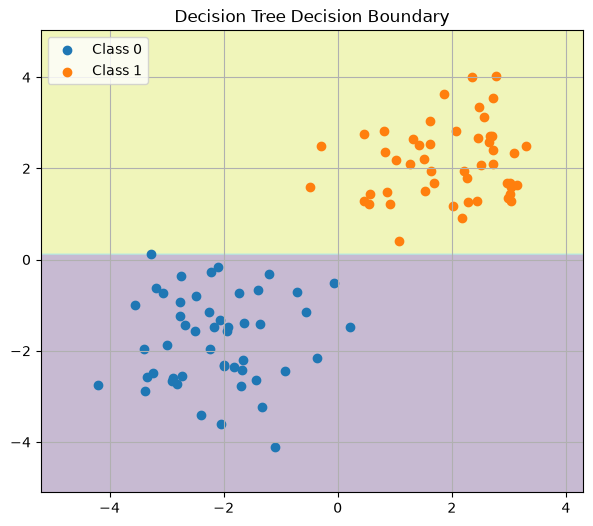

In [112]:
x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = torch.meshgrid(
    torch.linspace(x_min, x_max, 200),
    torch.linspace(y_min, y_max, 200),
    indexing="ij"
)

grid = torch.stack(
    [xx.reshape(-1), yy.reshape(-1)],
    dim=1
)

grid_pred = predict(grid, tree).reshape(xx.shape)

plt.figure(figsize=(7,6))

plt.contourf(
    xx.numpy(),
    yy.numpy(),
    grid_pred.numpy(),
    alpha=0.3
)

plt.scatter(
    X0[:,0],
    X0[:,1],
    label="Class 0"
)

plt.scatter(
    X1[:,0],
    X1[:,1],
    label="Class 1"
)

plt.legend()
plt.title("Decision Tree Decision Boundary")
plt.grid(True)
plt.show()